## Bow Tie Plot in Regression

Philipp Schlatter, LSTM FAU, 2026


Run in Colab: https://colab.research.google.com/github/pschlatt1/notebooks/blob/main/UA/bowtie.ipynb

The "bow tie" plot in regression analysis visualizes the Confidence Interval (CI) and Prediction Interval (PI) around a regression line. It is called a "bow tie" because the intervals are narrowest at the mean of the data and flare out (widen) as you move away from the center, resembling the shape of a bow tie.

Here is the mathematical derivation of why this happens, followed by a Python Jupyter Notebook example to generate the plot.


### Mathematical Derivation
To understand the bow tie shape, we must derive the variance of our predictions.

#### The Model

Consider a simple linear regression model:

$$Y = \beta_0 + \beta_1 x + \epsilon$$

where $\epsilon \sim N(0, \sigma^2)$. The predicted value ($\hat{y}_0$) for a specific input $x_0$ is given by:

$$\hat{y}_0 = \hat{\beta}_0 + \hat{\beta}_1 x_0$$

#### The Key Substitution

A standard result in regression is that $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$. Substituting this into the prediction equation allows us to express the prediction relative to the centroids ($\bar{x}, \bar{y}$):

$$\hat{y}_0 = (\bar{y} - \hat{\beta}_1 \bar{x}) + \hat{\beta}_1 x_0$$

$$\hat{y}_0 = \bar{y} + \hat{\beta}_1 (x_0 - \bar{x})$$

#### Variance of the Mean Response (Confidence Interval)

We want to find the variance of this prediction $Var(\hat{y}_0)$. Since $\bar{y}$ and $\hat{\beta}_1$ are uncorrelated, the variance is the sum of their variances:

$$Var(\hat{y}_0) = Var(\bar{y}) + (x_0 - \bar{x})^2 Var(\hat{\beta}_1)$$

Using the standard definitions $Var(\bar{y}) = \frac{\sigma^2}{n}$ and $Var(\hat{\beta}_1) = \frac{\sigma^2}{\sum (x_i - \bar{x})^2}$ (often noted as $S_{xx}$):

$$Var(\hat{y}_0) = \sigma^2 \left[ \frac{1}{n} + \frac{(x_0 - \bar{x})^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2} \right]$$

#### The Bow Tie Effect: 

Notice the numerator $(x_0 - \bar{x})^2$. When $x_0 = \bar{x}$ (at the center of your data), this term is zero. The variance is minimized ($\frac{\sigma^2}{n}$). As $|x_0 - \bar{x}|$ increases (moving away from the center), the variance increases quadratically. This causes the confidence bands to curve outward.

#### Variance of a New Observation (Prediction Interval)

If we are predicting a new single observation, we must add the irreducible error ($\epsilon$) of that new point:

$$Var(y_{new}) = Var(\hat{y}_0) + Var(\epsilon)$$

$$Var(y_{new}) = \sigma^2 \left[ 1 + \frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}} \right]$$

This creates an even wider "bow tie" around the data.

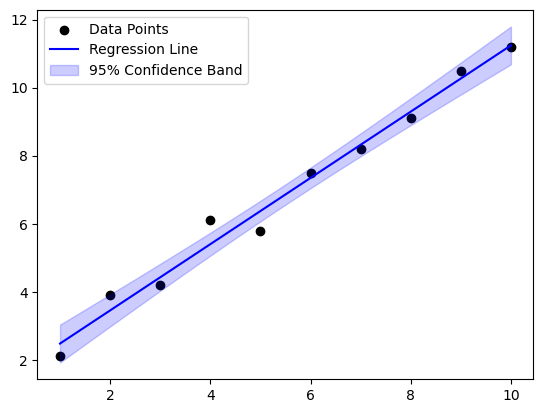

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Sample Data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([2.1, 3.9, 4.2, 6.1, 5.8, 7.5, 8.2, 9.1, 10.5, 11.2])

# 2. Linear Regression (Slope and Intercept)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
y_pred = intercept + slope * x

# 3. Parameters for the Bands
n = len(x)                          # Number of observations
dof = n - 2                         # Degrees of freedom
t_crit = stats.t.ppf(0.975, dof)    # Inverse CDF for 95% confidence

# Residual sum of squares and Standard Error of Estimate
resid = y - y_pred
s_err = np.sqrt(np.sum(resid**2) / dof) 

# 4. Calculate bands across a smooth range of X
x_fine = np.linspace(x.min(), x.max(), 100)
y_fine = intercept + slope * x_fine

# The core "Bow Tie" math
x_mean = np.mean(x)
ss_xx = np.sum((x - x_mean)**2)

# Standard Error for the Confidence Band
se_conf = s_err * np.sqrt(1/n + (x_fine - x_mean)**2 / ss_xx)

# Standard Error for the Prediction Band
se_pred = s_err * np.sqrt(1 + 1/n + (x_fine - x_mean)**2 / ss_xx)

# 5. Plotting
plt.scatter(x, y, color='black', label='Data Points')
plt.plot(x_fine, y_fine, color='blue', label='Regression Line')

# Confidence Band (The tight bow tie)
plt.fill_between(x_fine, y_fine - t_crit*se_conf, y_fine + t_crit*se_conf, 
                 color='blue', alpha=0.2, label='95% Confidence Band')

# Prediction Band (The wider bow tie)
#plt.plot(x_fine, y_fine - t_crit*se_pred, '--', color='red', label='95% Prediction Interval')
#plt.plot(x_fine, y_fine + t_crit*se_pred, '--', color='red')

plt.legend()
plt.show()

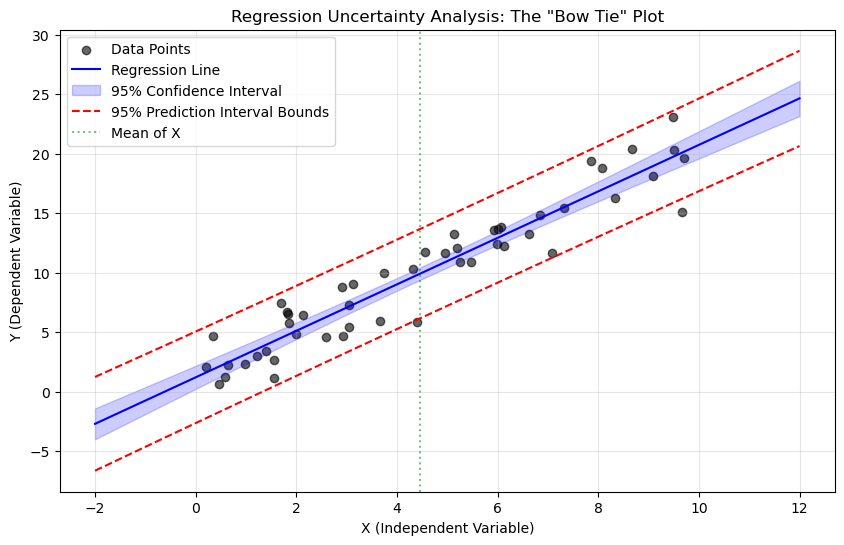

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Generate Synthetic Data
np.random.seed(42)
n = 50
x = np.random.uniform(0, 10, n)
# True parameters: y = 2x + 1 + noise
y = 2 * x + 1 + np.random.normal(0, 2, n)

# 2. Fit Linear Regression Parameters (Manual Calculation)
x_mean = np.mean(x)
y_mean = np.mean(y)

# Calculate Sxx (Sum of squared differences for x)
Sxx = np.sum((x - x_mean)**2)

# Calculate beta_1 (Slope) and beta_0 (Intercept)
beta_1 = np.sum((x - x_mean) * (y - y_mean)) / Sxx
beta_0 = y_mean - beta_1 * x_mean

# 3. Calculate Variance and Residuals
y_hat = beta_0 + beta_1 * x
residuals = y - y_hat
# Unbiased estimate of error variance (sigma^2)
sigma_squared = np.sum(residuals**2) / (n - 2)

# 4. Generate Grid for Plotting the Bow Tie
# We extend the grid beyond the data range to exaggerate the bow tie effect
x_grid = np.linspace(-2, 12, 100)
y_pred_grid = beta_0 + beta_1 * x_grid

# 5. Calculate Intervals
t_crit = stats.t.ppf(0.975, df=n-2) # 95% Confidence (two-tailed)

ci_bands = [] # Confidence Interval (Mean Response)
pi_bands = [] # Prediction Interval (New Observation)

for x0 in x_grid:
    # Common term: (x0 - x_mean)^2 / Sxx
    distance_term = (x0 - x_mean)**2 / Sxx
    
    # Standard Error for Mean Response (CI)
    se_mean = np.sqrt(sigma_squared * (1/n + distance_term))
    
    # Standard Error for New Observation (PI)
    se_pred = np.sqrt(sigma_squared * (1 + 1/n + distance_term))
    
    ci_bands.append(t_crit * se_mean)
    pi_bands.append(t_crit * se_pred)

ci_bands = np.array(ci_bands)
pi_bands = np.array(pi_bands)

# 6. Plotting
plt.figure(figsize=(10, 6))

# Plot raw data
plt.scatter(x, y, color='black', alpha=0.6, label='Data Points')

# Plot regression line
plt.plot(x_grid, y_pred_grid, color='blue', label='Regression Line')

# Plot Confidence Interval (The Inner Bow Tie)
plt.fill_between(x_grid, 
                 y_pred_grid - ci_bands, 
                 y_pred_grid + ci_bands, 
                 color='blue', alpha=0.2, label='95% Confidence Interval')

# Plot Prediction Interval (The Outer Bow Tie)
plt.plot(x_grid, y_pred_grid - pi_bands, color='red', linestyle='--', label='95% Prediction Interval Bounds')
plt.plot(x_grid, y_pred_grid + pi_bands, color='red', linestyle='--')

# Highlight the center
plt.axvline(x_mean, color='green', linestyle=':', alpha=0.5, label='Mean of X')

plt.title('Regression Uncertainty Analysis: The "Bow Tie" Plot')
plt.xlabel('X (Independent Variable)')
plt.ylabel('Y (Dependent Variable)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('ppp.svg')
plt.show()